# Ridge Regression

Ridge Regression is a regularized version of **Linear Regression** that adds an **L2 penalty** to the loss function to shrink coefficients and reduce overfitting.

## Cost Function

Ordinary Least Squares (OLS) minimizes:

$$ J(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

Ridge adds a penalty term proportional to the **squared magnitude** of the coefficients:

$$ J(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} \beta_j^2 $$

Where:
- $\alpha \geq 0$ is the regularization strength (hyperparameter).
- Larger $\alpha$ → more shrinkage → simpler model (higher bias, lower variance).
- $\alpha = 0$ → equivalent to plain Linear Regression.

## Closed-form Solution

$$ \hat{\beta} = (X^T X + \alpha I)^{-1} X^T y $$

The added $\alpha I$ term makes $X^T X$ invertible even when features are correlated (handles multicollinearity).

## When to use Ridge?
- Many features, possibly correlated (multicollinearity).
- Want to keep all features but reduce their influence.
- To prevent overfitting in linear models.

> **Note:** Ridge does **not** perform feature selection (coefficients shrink toward 0 but rarely become exactly 0). Use **Lasso** for feature selection.

---

## 1. Import Required Libraries

## Key Intuitions for Ridge Regression

Five core ideas — read these before the code.

### 1. As `alpha` ↑ , coefficients shrink toward 0
Ridge minimizes:

$$ J(\beta) = \underbrace{\sum (y_i - \hat{y}_i)^2}_{\text{fit data}} + \alpha \underbrace{\sum \beta_j^2}_{\text{stay small}} $$

The optimizer is now juggling **two goals**: fit the data **and** keep $\beta$ small. As `alpha` grows, the second goal dominates, so coefficients are pulled toward 0. In the closed-form solution

$$ \hat{\beta} = (X^T X + \alpha I)^{-1} X^T y $$

the `+ αI` term inflates the matrix being inverted → smaller coefficients come out.

---

### 2. **Larger** coefficients are penalized **more** (it's quadratic)
The penalty is $\alpha \sum \beta_j^2$ — squared. So:

| Coefficient | Penalty contribution |
|---|---|
| $\beta = 1$  | $\alpha \cdot 1 = \alpha$ |
| $\beta = 5$  | $\alpha \cdot 25 = 25\alpha$ |
| $\beta = 10$ | $\alpha \cdot 100 = 100\alpha$ |

Doubling a coefficient **quadruples** its cost. So the optimizer aggressively shrinks the **largest** coefficients first — that's why Ridge curves "fan in" as `alpha` grows in the regularization-path plot.

---

### 3. `alpha` controls the bias–variance trade-off

| `alpha` | Coefficients | Model | Bias | Variance | Risk |
|---|---|---|---|---|---|
| **Low (≈ 0)** | Free, possibly huge | Complex | **Low** | **High** | **Overfits** training data |
| **High** | Heavily shrunk toward 0 | Simple | **High** | **Low** | **Underfits** — misses real patterns |
| **Just right** (CV-tuned) | Balanced | — | Moderate | Moderate | **Best generalization** |

Mental model: `alpha` is a **complexity dial**. Turn it up → simpler model, less overfitting, but more bias.  
Goal: pick the `alpha` that **minimizes total error** = bias² + variance + noise. That's exactly what `RidgeCV` does.

---

### 4. How `alpha` reshapes the loss function

Visualize the loss surface in $(\beta_1, \beta_2)$ space:

- **Without regularization (`alpha = 0`)**: contours are **stretched ellipses** (some directions are weakly informative). The minimum can sit far from the origin and is sensitive to noise.
- **With regularization (`alpha > 0`)**: we add a **bowl** $\alpha(\beta_1^2 + \beta_2^2)$ centered at the origin. The combined surface = ellipses + bowl → contours become **rounder** and the minimum is **dragged toward the origin**.

Equivalently, Ridge solves a constrained problem:

$$ \min_\beta \| y - X\beta \|^2 \quad \text{subject to} \quad \sum \beta_j^2 \le t $$

The constraint region is a **disk** centered at 0. Larger `alpha` ⇔ smaller disk ⇔ stronger pull toward the origin. The solution sits where the OLS ellipses first touch this disk.

---

### 5. Ridge does **not** zero-out features (no feature selection)
The L2 penalty is **smooth** at $\beta = 0$ (gradient $= 2\alpha\beta$, which is **0 itself** when $\beta = 0$). There is no "kink" to push a coefficient onto exactly 0 — useless features just shrink to **very small but non-zero** values.

To get **exact zeros** (true feature selection), use **Lasso** (L1 penalty), whose absolute-value penalty has a corner at 0 that does push coefficients all the way to it.

> **TL;DR:** Ridge keeps every feature but quietly mutes the ones that aren't pulling their weight; Lasso fires the underperformers outright.

---


In [12]:
# Core libraries for data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn utilities
from sklearn.datasets import load_diabetes              # Built-in regression dataset
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler         # Ridge is sensitive to feature scale
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

# Reproducibility
np.random.seed(42)

## 2. Load and Explore the Dataset

We use the **Diabetes** dataset from scikit-learn — a classic regression dataset with 10 baseline features (age, sex, BMI, BP, and six blood serum measurements) used to predict disease progression after one year.

In [13]:
# Load the diabetes dataset from sklearn
data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
X.head()

Feature matrix shape: (442, 10)
Target shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [14]:
# Quick statistical overview of the features
X.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


## 3. Train / Test Split and Feature Scaling

Ridge Regression penalizes coefficient magnitudes, so features on different scales are penalized unfairly.  
**Always standardize features** before applying Ridge.

In [15]:
# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features: mean=0, std=1
# Fit on the training data only to avoid data leakage from the test set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train_scaled.shape)
print("Test size :", X_test_scaled.shape)

Train size: (353, 10)
Test size : (89, 10)


## 4. Baseline: Plain Linear Regression

Train an unregularized linear model first as a baseline for comparison.

In [16]:
# Fit ordinary linear regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predictions on the test set
y_pred_lr = lr.predict(X_test_scaled)

# Evaluation metrics
print("Linear Regression")
print(f"  R^2 : {r2_score(y_test, y_pred_lr):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}")

Linear Regression
  R^2 : 0.4526
  RMSE: 53.8534


## 5. Ridge Regression (fixed alpha)

Now train a Ridge model with a chosen regularization strength `alpha`.

In [17]:
# Fit Ridge regression with alpha=1.0 (default)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# Predictions on the test set
y_pred_ridge = ridge.predict(X_test_scaled)

# Evaluation metrics
print("Ridge Regression (alpha=1.0)")
print(f"  R^2 : {r2_score(y_test, y_pred_ridge):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}")

Ridge Regression (alpha=1.0)
  R^2 : 0.4541
  RMSE: 53.7775


## 6. Effect of `alpha` on Coefficients

As `alpha` increases, all coefficients are pulled toward zero (but rarely become exactly zero).  
This visualization shows the **regularization path**.

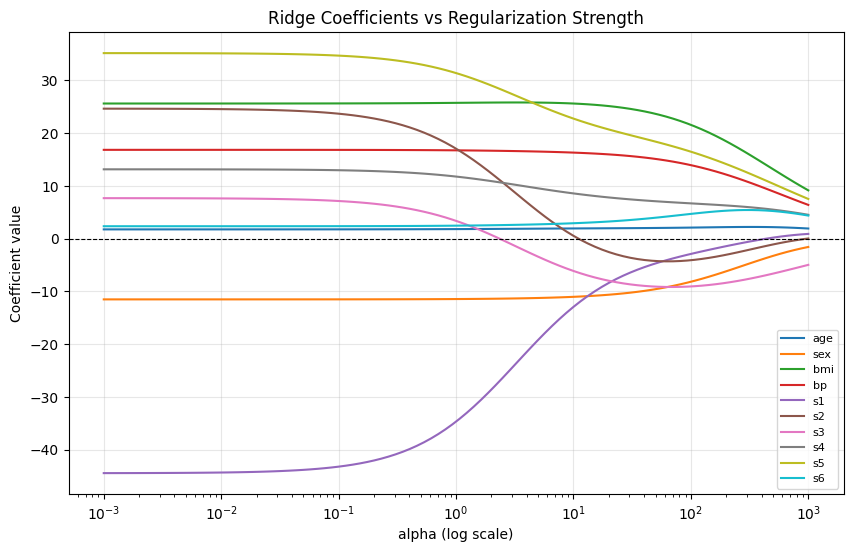

In [18]:
# Try a wide range of alpha values on a log scale
alphas = np.logspace(-3, 3, 100)
coefs = []

# Refit Ridge for each alpha and store its coefficients
for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    coefs.append(model.coef_)

coefs = np.array(coefs)

# Plot how each coefficient evolves as alpha grows
plt.figure(figsize=(10, 6))
for i, feature in enumerate(X.columns):
    plt.plot(alphas, coefs[:, i], label=feature)

plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Coefficient value")
plt.title("Ridge Coefficients vs Regularization Strength")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.legend(loc="best", fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()

## 7. Choosing the Best `alpha` with Cross-Validation

`RidgeCV` performs efficient cross-validation across a grid of `alpha` values and picks the best one automatically.

In [19]:
# RidgeCV: search over a grid of alphas using 5-fold cross-validation
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge_cv.fit(X_train_scaled, y_train)

print(f"Best alpha selected by CV: {ridge_cv.alpha_:.4f}")

# Evaluate the tuned model on the held-out test set
y_pred_cv = ridge_cv.predict(X_test_scaled)
print(f"Tuned Ridge R^2 : {r2_score(y_test, y_pred_cv):.4f}")
print(f"Tuned Ridge RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_cv)):.4f}")

Best alpha selected by CV: 44.9843
Tuned Ridge R^2 : 0.4608
Tuned Ridge RMSE: 53.4494


## 8. Compare Coefficients: Linear vs Ridge

Notice how Ridge coefficients are smaller in magnitude than ordinary Linear Regression — that is the **shrinkage effect** of L2 regularization.

In [20]:
# Build a side-by-side comparison of the coefficients
comparison = pd.DataFrame({
    "Feature": X.columns,
    "LinearRegression": lr.coef_,
    "Ridge (alpha=1)": ridge.coef_,
    f"RidgeCV (alpha={ridge_cv.alpha_:.2f})": ridge_cv.coef_,
})
comparison

,Feature,LinearRegression,Ridge (alpha=1),RidgeCV (alpha=44.98)
0,age,1.753758,1.807342,2.014184
1,sex,-11.511809,-11.448190,-9.739642
2,bmi,25.607121,25.732699,23.884661
3,bp,16.828872,16.734300,15.240183
4,s1,-44.448856,-34.671954,-5.026594
5,s2,24.640954,17.053075,-4.161414
6,s3,7.676978,3.369914,-9.035551
7,s4,13.138784,11.764260,7.156604
8,s5,35.161195,31.378384,18.648344
9,s6,2.351364,2.458139,3.864162


## 9. Cross-Validated Performance vs `alpha`

Plot the average CV score for each `alpha` to visually verify the optimal regularization strength.

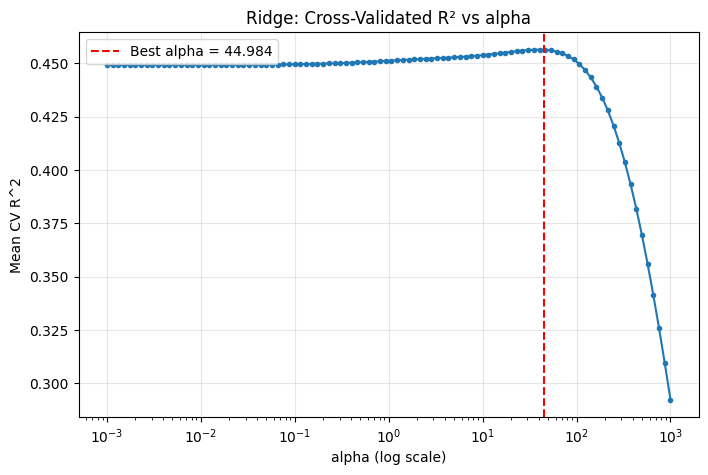

In [21]:
# Compute mean 5-fold CV R^2 for each alpha
cv_scores = []
for a in alphas:
    score = cross_val_score(
        Ridge(alpha=a), X_train_scaled, y_train,
        cv=5, scoring="r2"
    ).mean()
    cv_scores.append(score)

# Plot CV score vs alpha
plt.figure(figsize=(8, 5))
plt.plot(alphas, cv_scores, marker="o", markersize=3)
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Mean CV R^2")
plt.title("Ridge: Cross-Validated R² vs alpha")
plt.axvline(ridge_cv.alpha_, color="red", linestyle="--",
            label=f"Best alpha = {ridge_cv.alpha_:.3f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Summary

- **Ridge Regression** = Linear Regression + L2 penalty $\alpha \sum \beta_j^2$.
- It **shrinks** coefficients, helping with **multicollinearity** and **overfitting**.
- Always **standardize features** before applying Ridge.
- Use `RidgeCV` (or `GridSearchCV`) to choose the best `alpha`.
- Ridge keeps all features; for sparse models / feature selection, use **Lasso** (L1) or **ElasticNet** (L1 + L2).

## 11. Demo: What Happens Without Standardization?

Ridge's L2 penalty $\alpha \sum \beta_j^2$ is **scale-sensitive** — features with larger numerical ranges produce smaller coefficients (and escape the penalty), while features with small ranges need bigger coefficients (and get crushed).

Below we demonstrate this by:

1. Fitting Ridge on the **raw** (unscaled) features.
2. Artificially blowing up one feature by a factor of 1000 and refitting.
3. Comparing predictions and coefficients across all three setups.

In [22]:
# NOTE: sklearn's diabetes dataset is already mean-centered & scaled.
# To make the effect of "no standardization" visible, we deliberately
# create a version where features have very DIFFERENT scales:
#   - bmi is multiplied by 1000  (now huge numbers)
#   - bp  is divided by 1000     (now tiny numbers)
# Every other feature is left as-is.

X_train_mixed = X_train.copy()
X_test_mixed = X_test.copy()

X_train_mixed["bmi"] *= 1000
X_test_mixed["bmi"]  *= 1000

X_train_mixed["bp"] /= 1000
X_test_mixed["bp"]  /= 1000

# Compare the ranges
pd.DataFrame({
    "original_std": X_train.std(),
    "mixed_std":    X_train_mixed.std(),
})

,original_std,mixed_std
age,0.046334,0.046334
sex,0.047644,0.047644
bmi,0.047275,47.275276
bp,0.048469,0.000048
s1,0.047786,0.047786
s2,0.047631,0.047631
s3,0.047044,0.047044
s4,0.047790,0.047790
s5,0.047828,0.047828
s6,0.048380,0.048380


In [23]:
# Fit Ridge on the deliberately mis-scaled data (NO standardization)
ridge_mixed = Ridge(alpha=1.0)
ridge_mixed.fit(X_train_mixed, y_train)
y_pred_mixed = ridge_mixed.predict(X_test_mixed)

# For reference: Ridge on properly STANDARDIZED data (already trained earlier)
y_pred_scaled = ridge.predict(X_test_scaled)

print("Ridge (alpha=1.0) — mis-scaled, NO standardization")
print(f"  R^2 : {r2_score(y_test, y_pred_mixed):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_mixed)):.4f}")

print("\nRidge (alpha=1.0) — properly STANDARDIZED")
print(f"  R^2 : {r2_score(y_test, y_pred_scaled):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_scaled)):.4f}")

Ridge (alpha=1.0) — mis-scaled, NO standardization
  R^2 : 0.3767
  RMSE: 57.4644

Ridge (alpha=1.0) — properly STANDARDIZED
  R^2 : 0.4541
  RMSE: 53.7775


In [24]:
# Compare coefficients across the two fits.
# Watch what happens to `bmi` (blown up x1000) and `bp` (shrunk /1000):
#   - bmi's coefficient becomes tiny (it doesn't NEED to be big to have impact
#     because the feature itself is huge -> escapes the L2 penalty).
#   - bp's coefficient must become huge to have any effect, so the L2 penalty
#     hammers it down -> the model can no longer use bp effectively.

coef_compare = pd.DataFrame({
    "Feature": X.columns,
    "Ridge (mis-scaled, no std)": ridge_mixed.coef_,
    "Ridge (standardized)":       ridge.coef_,
})
coef_compare

,Feature,"Ridge (mis-scaled, no std)",Ridge (standardized)
0,age,45.483279,1.807342
1,sex,-48.816917,-11.448190
2,bmi,0.819919,25.732699
3,bp,0.232201,16.734300
4,s1,-9.321965,-34.671954
5,s2,-45.472628,17.053075
6,s3,-95.939560,3.369914
7,s4,75.925680,11.764260
8,s5,185.152602,31.378384
9,s6,76.972617,2.458139


In [25]:
# The "best" alpha also depends on scale.
# Run RidgeCV on the mis-scaled data and compare to the standardized version.

ridge_cv_mixed = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge_cv_mixed.fit(X_train_mixed, y_train)

print(f"Best alpha — mis-scaled data : {ridge_cv_mixed.alpha_:.4f}")
print(f"Best alpha — standardized    : {ridge_cv.alpha_:.4f}")
print("\nThe optimal regularization strength changes purely because of"
      "\nfeature scaling — the underlying data is the same.")

Best alpha — mis-scaled data : 0.0910
Best alpha — standardized    : 44.9843

The optimal regularization strength changes purely because of
feature scaling — the underlying data is the same.


### Takeaways from the demo

- **Coefficients are no longer comparable.** Features with large units get tiny coefficients (and dodge the penalty); features with small units get huge coefficients (and get over-shrunk).
- **The chosen `alpha` becomes meaningless across runs** — it depends entirely on your unit choices.
- **Predictions degrade**, especially when an important feature happens to live on a small scale.
- **Fix:** always wrap Ridge in a `Pipeline(StandardScaler → Ridge)` so scaling is applied consistently to train and test data and inside CV folds.